# Figure 1e

This notebook recreates the visualization shown in figure 1e in the reference article.

> Same t-SNE plot as (C) [t-SNE plot of the integrated scRNA-seq profiles of epithelial cells form 11 reduction mammoplasties.] but colored by cell clusters (with Suerat cluster resolution set to 0.015)

<div style="text-align: center;">
    <img src="images/figure-1e-reference.png" alt="Figure 1e from Reference Article" width="50%">
    <p style="font-size:90%; color:gray; text-align: center;"><em>Figure 1e from Reference Article</em></p>
</div>

## 0. Initializations

In [1]:
# -- imports --
from signals_in_the_noise.preprocessing.gse161529 import GSE161529
from signals_in_the_noise.utils.visualization import get_figure_axes

In [2]:
# -- dataset --
gse = GSE161529()
all_real, all_noise = gse.get_combined_epithelial_dataset(real_pca_kwargs={}, noise_pca_kwargs={}, hvg_post_stromal=False)

## 1. "Real" cells

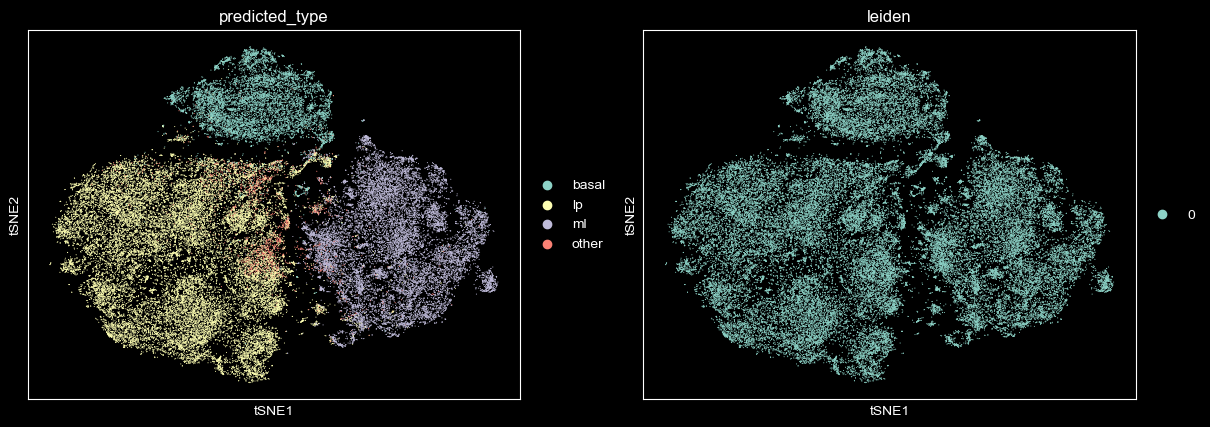

In [3]:
gse.visualize_tsne(all_real, color=['predicted_type', 'leiden'])

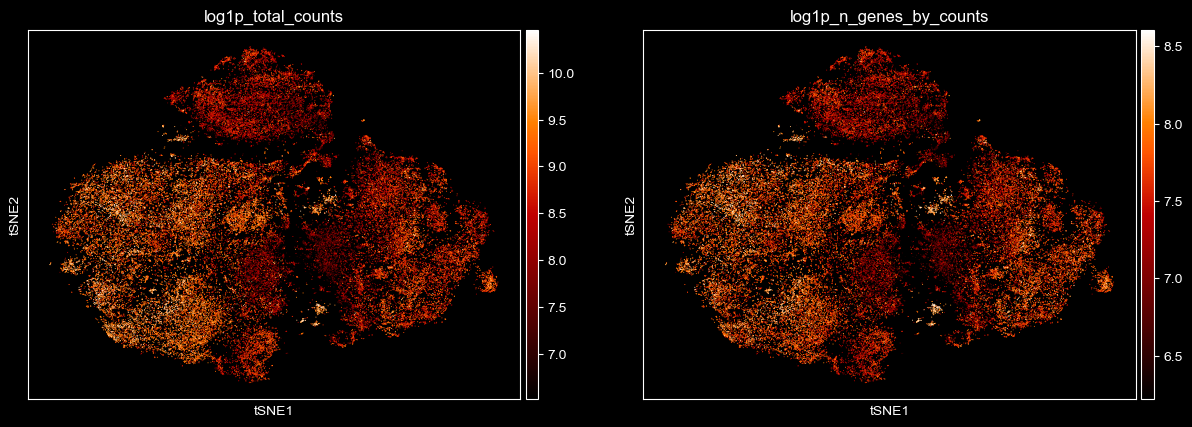

In [4]:
gse.visualize_tsne(all_real, color=['log1p_total_counts', 'log1p_n_genes_by_counts'], plot_kwargs={'cmap': 'gist_heat'})

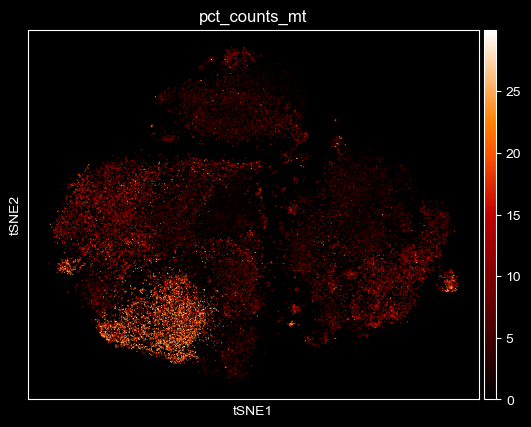

In [5]:
gse.visualize_tsne(all_real, color=['pct_counts_mt'], plot_kwargs={'cmap': 'gist_heat'})

## 2. "Noise" cells

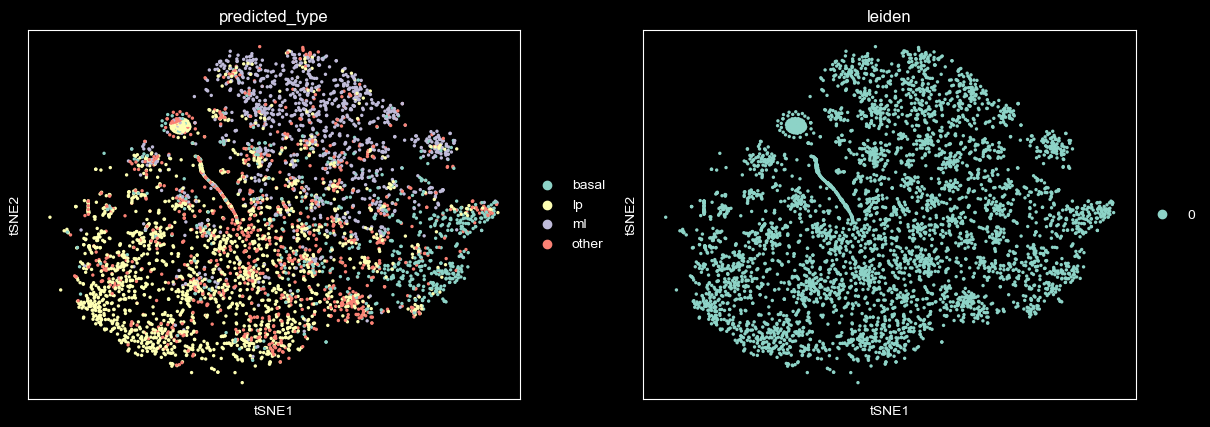

In [6]:
gse.visualize_tsne(all_noise, color=['predicted_type', 'leiden'])

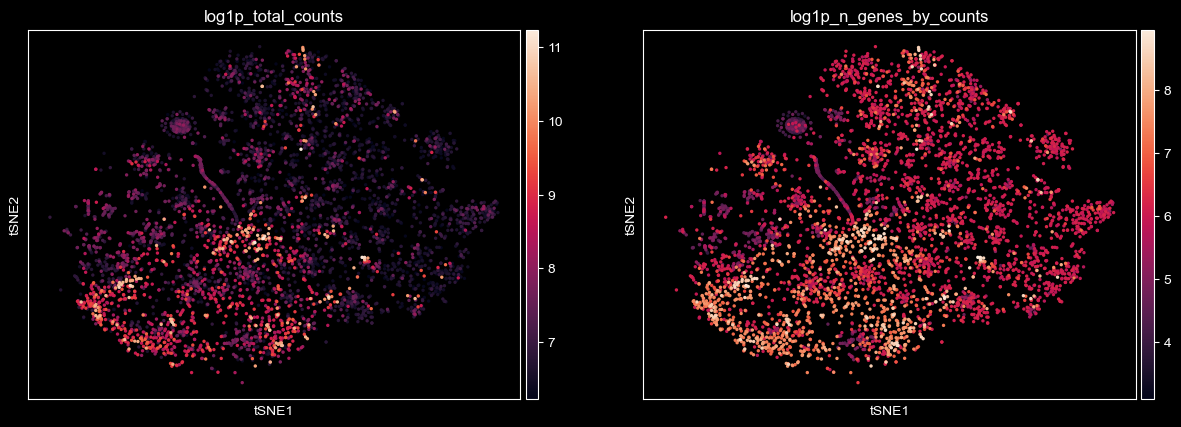

In [7]:
gse.visualize_tsne(all_noise, color=['log1p_total_counts', 'log1p_n_genes_by_counts'])

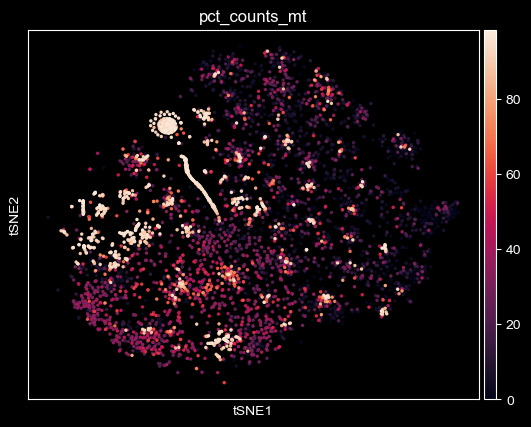

In [8]:
gse.visualize_tsne(all_noise, color=['pct_counts_mt'])

In [9]:
import scanpy as sc
sc.tl.umap(all_noise)
sc.tl.umap(all_real)

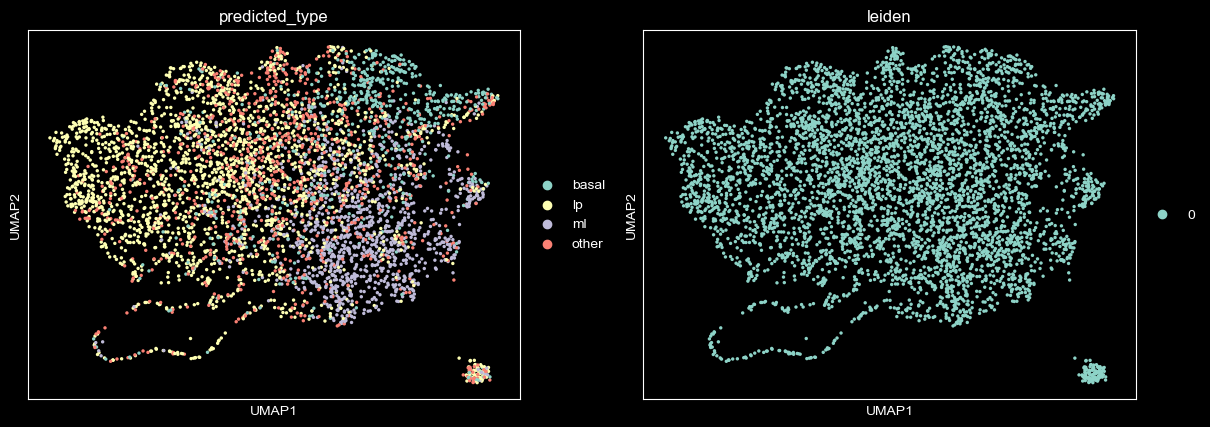

In [10]:
sc.pl.umap(all_noise, color=['predicted_type', 'leiden'])

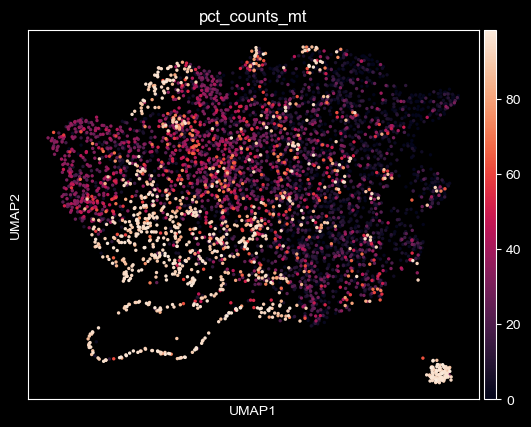

In [11]:
sc.pl.umap(all_noise, color=['pct_counts_mt'])

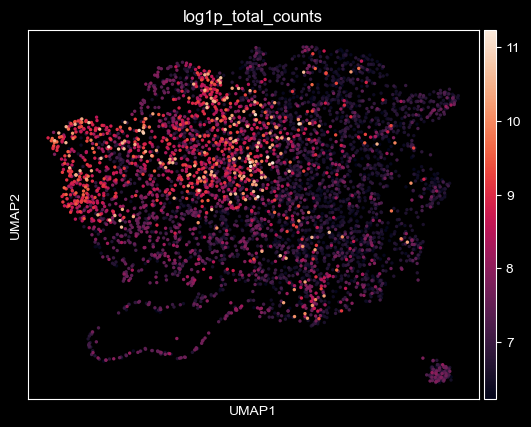

In [12]:
sc.pl.umap(all_noise, color=['log1p_total_counts'])

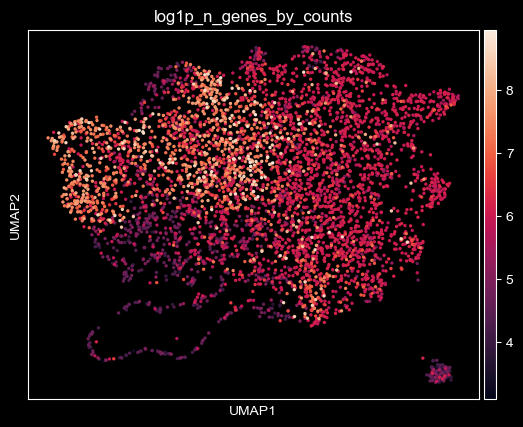

In [13]:
sc.pl.umap(all_noise, color=['log1p_n_genes_by_counts'])

## for poster

In [14]:
import matplotlib.colors as mcolors
import pandas as pd

from signals_in_the_noise.analysis.noise_phenotypes import Thresholds
from signals_in_the_noise.utils.visualization import umap_threshold_colormap, umap_threshold_plot_order


def umap_palette_for_threshold(
    values: pd.Series,
    thresholds: Thresholds,
) -> tuple[mcolors.LinearSegmentedColormap, float, float]:
    """Return a UMAP colormap that highlights cells matching ``thresholds``."""
    return umap_threshold_colormap(values, thresholds)


# Example:
# metric = all_noise.obs["log1p_total_counts"]
# thresholds = pbs_1_thresholds.log1p_total_counts
# palette, vmin, vmax = umap_palette_for_threshold(metric, thresholds)
# order = umap_threshold_plot_order(metric, thresholds)
# sc.pl.umap(
#     all_noise[order],
#     color=["log1p_total_counts"],
#     cmap=palette,
#     vmin=vmin,
#     vmax=vmax,
#     sort_order=False,
# )

In [15]:
from signals_in_the_noise.analysis.noise_phenotypes import PbsThresholds

pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.85, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=0.95, q_high=None, q_mod_low=None, q_mod_high=None),
)

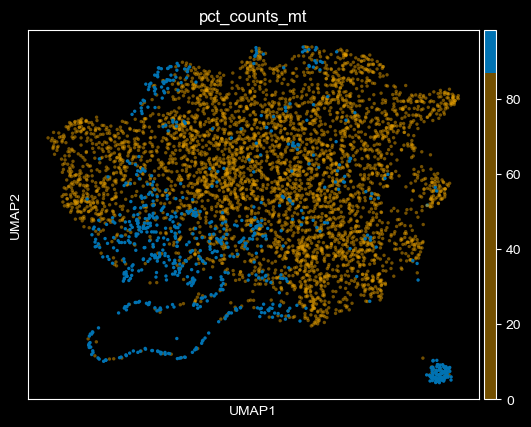

In [16]:
from signals_in_the_noise.utils.visualization import umap_threshold_plot_order

# pbs-1: high mitochondrial fraction (pct_counts_mt >= q85)
metric = all_noise.obs["pct_counts_mt"]
thresholds = pbs_1_thresholds.pct_counts_mt
palette, vmin, vmax = umap_palette_for_threshold(metric, thresholds)
order = umap_threshold_plot_order(metric, thresholds)
sc.pl.umap(
    all_noise[order],
    color=["pct_counts_mt"],
    cmap=palette,
    vmin=vmin,
    vmax=vmax,
    sort_order=False,
)

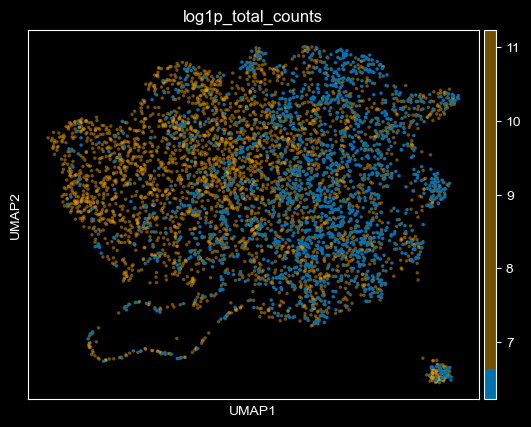

In [17]:
# pbs-1: low total RNA (log1p_total_counts <= q30)
metric = all_noise.obs["log1p_total_counts"]
thresholds = pbs_1_thresholds.log1p_total_counts
palette, vmin, vmax = umap_palette_for_threshold(metric, thresholds)
order = umap_threshold_plot_order(metric, thresholds)
sc.pl.umap(
    all_noise[order],
    color=["log1p_total_counts"],
    cmap=palette,
    vmin=vmin,
    vmax=vmax,
    sort_order=False,
)

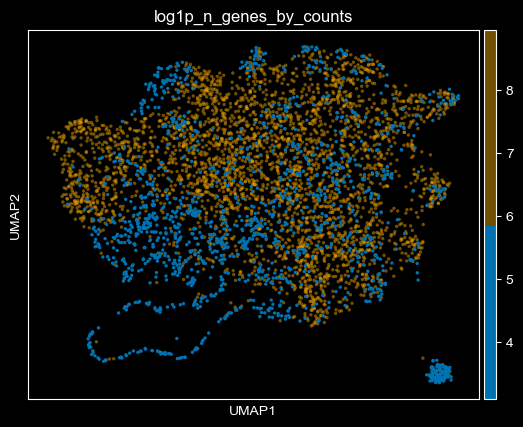

In [18]:
# pbs-1: low gene count (log1p_n_genes_by_counts <= q30)
metric = all_noise.obs["log1p_n_genes_by_counts"]
thresholds = pbs_1_thresholds.log1p_n_genes_by_counts
palette, vmin, vmax = umap_palette_for_threshold(metric, thresholds)
order = umap_threshold_plot_order(metric, thresholds)
sc.pl.umap(
    all_noise[order],
    color=["log1p_n_genes_by_counts"],
    cmap=palette,
    vmin=vmin,
    vmax=vmax,
    sort_order=False,
)